In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from remake2 import load_remake

In [2]:
cd /home/users/mmuetz/projects/mcs_prime_stoch_trigger/ctrl/remakefiles

/home/users/mmuetz/projects/mcs_prime_stoch_trigger/ctrl/remakefiles


In [3]:
rmk = load_remake('N216_sims_process.py')

2024-09-12 13:12:34.491 | DEBUG    | remake2.remake_base:load_rules:56 - Loading rules
2024-09-12 13:12:34.513 | DEBUG    | remake2.remake_base:load_rules:81 - inserting rules
2024-09-12 13:12:34.800 | DEBUG    | remake2.remake_base:finalize:173 - getting task status
2024-09-12 13:12:34.818 | DEBUG    | remake2.remake_base:load_rules:94 - Loaded rules


In [4]:
output = [o for t in rmk.tasks for o in t.outputs.values()]

In [5]:
pngs = [o for o in output if o.suffix == '.png']

In [6]:
import fnmatch

class PngDisp:
    def __init__(self, pngs):
        self.pngs = pngs

    def _filter_pngs(self, png_filter):
        return fnmatch.filter([str(p) for p in self.pngs], '*' + png_filter + '*')
        
    def display(self, png_filter=''):
        for png in self._filter_pngs(png_filter):
            print(png)
            img = mpimg.imread(png)
            fig, ax = plt.subplots(figsize=(img.shape[1] / 100, img.shape[0] / 100))
            fig.patch.set_visible(False)
            ax.axis('off')
            ax.imshow(img)
            
    def grid_display(self, grid):
        """grid should be a 2D grid, containing strings to filter pngs by

        each filter must return only one png, and they must all have same shape"""
        imgs = []
        grid = np.array(grid)
        for png_filter in grid.flatten():
            if png_filter is None:
                imgs.append(None)
                continue
            pngs = self._filter_pngs(png_filter)
            assert len(pngs) == 1
            png = pngs[0]
            img = mpimg.imread(png)
            imgs.append(img)
        assert all([imgs[0].shape == img.shape for img in imgs[1:]]), 'not all images have same shape'
        figsize = (grid.shape[1] * imgs[0].shape[1] / 100, grid.shape[0] * imgs[0].shape[0] / 100)
        fig, axes = plt.subplots(grid.shape[0], grid.shape[1], figsize=figsize, layout='constrained')
        fig.patch.set_visible(False)

        for ax, img, title in zip(axes.flatten(), imgs, grid.flatten()):
            ax.axis('off')
            ax.set_title(title)
            if img is not None:
                ax.imshow(img)

png_disp = PngDisp(pngs)
        

/gws/nopw/j04/mcs_prime/mmuetz/data/mcs_prime_figs/N216sims/precip_autocorr.png
/gws/nopw/j04/mcs_prime/mmuetz/data/mcs_prime_figs/N216sims/spread_skill.smooth=False-show_skill_minus_spread=True.png
/gws/nopw/j04/mcs_prime/mmuetz/data/mcs_prime_figs/N216sims/spread_skill.smooth=24.png
/gws/nopw/j04/mcs_prime/mmuetz/data/mcs_prime_figs/N216sims/spread_skill.xlim=(0,20).png
/gws/nopw/j04/mcs_prime/mmuetz/data/mcs_prime_figs/N216sims/spread_skill.xlim=(0,48).png
/gws/nopw/j04/mcs_prime/mmuetz/data/mcs_prime_figs/N216sims/total_precip.png


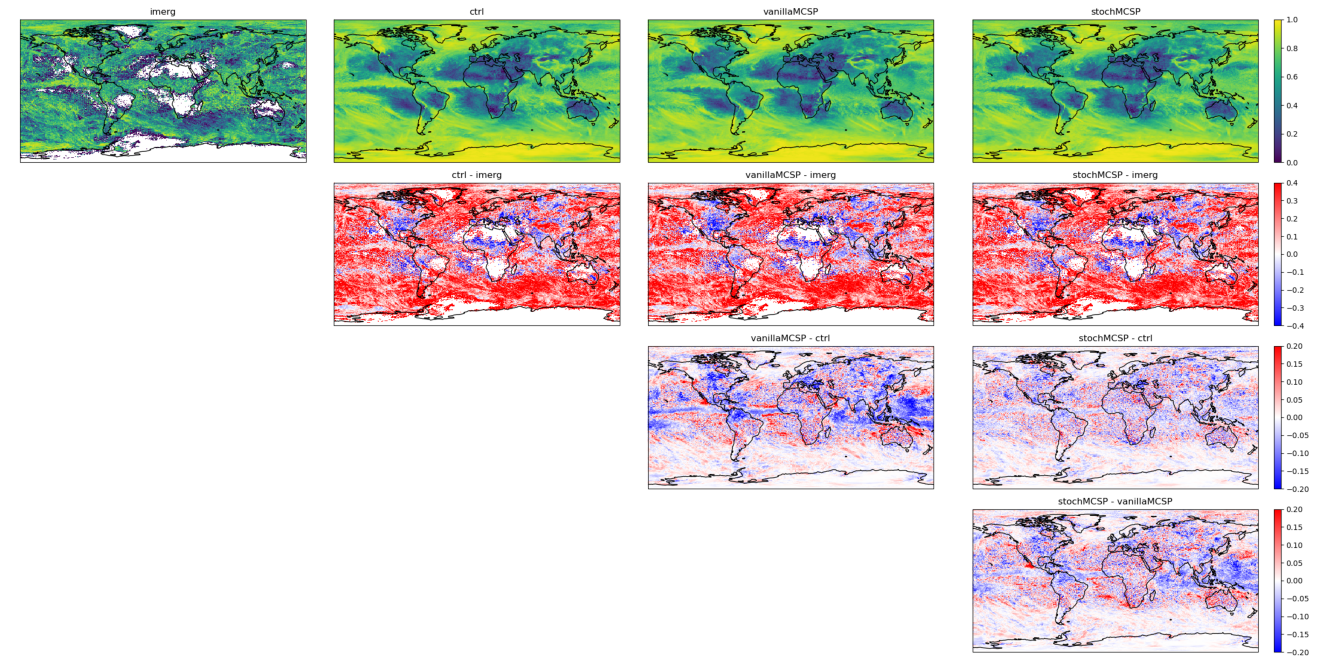

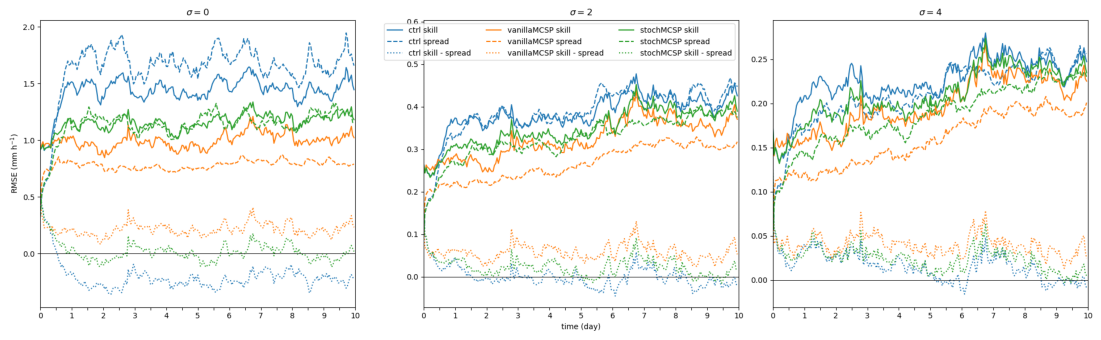

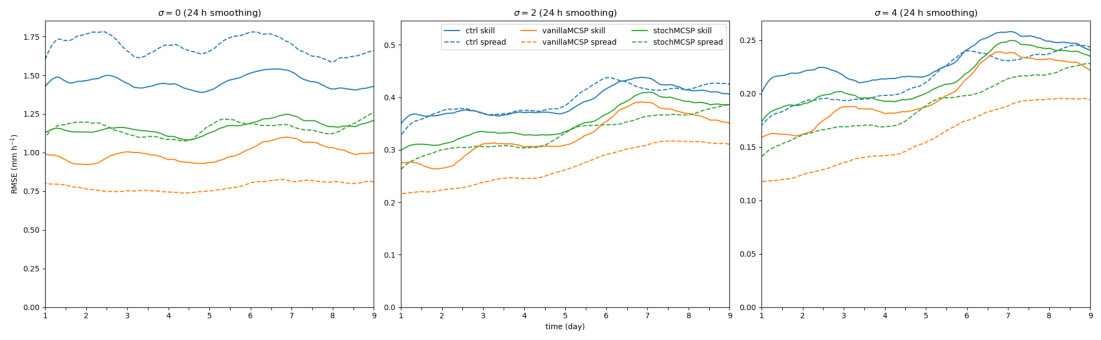

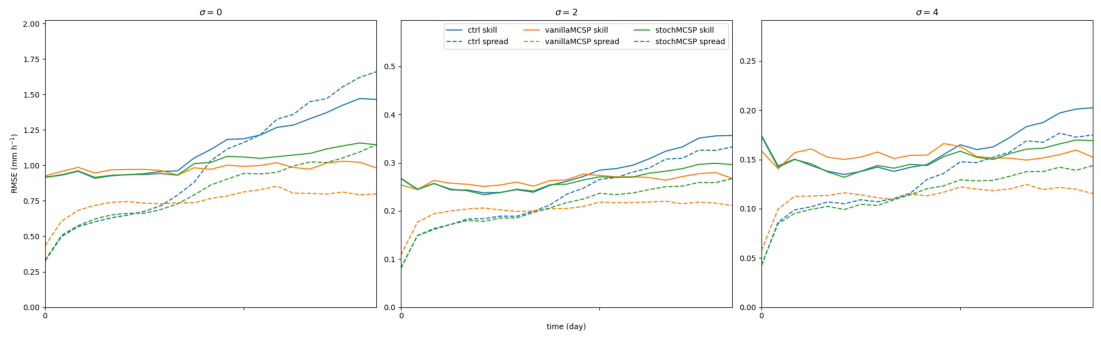

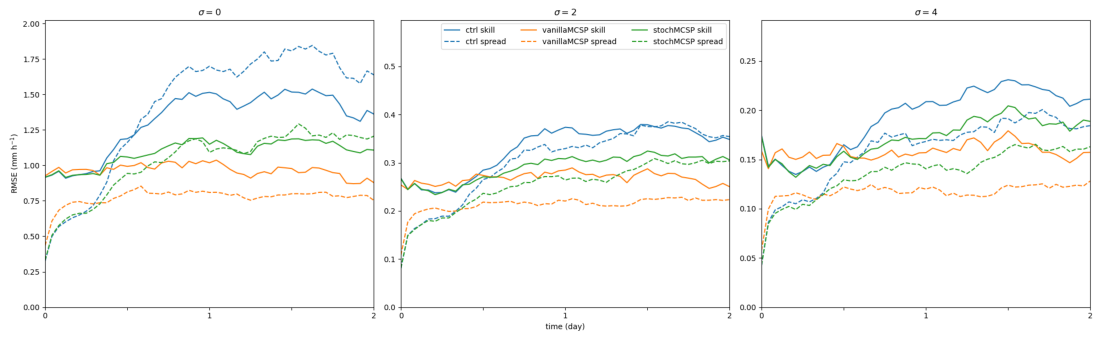

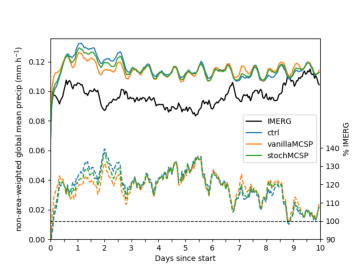

In [8]:
png_disp.display()